### Instalasi Library

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import warnings
from pathlib import Path
import joblib
import json
warnings.filterwarnings("ignore")

## **LOAD DATA DAN PENGECEKAN DATA**

### load data

In [18]:
DATA_PATH = "diabetes.csv"
data = pd.read_csv(DATA_PATH)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1


In [19]:
# Cek missing values dan nilai 0 dan data duplikasi
print("\nNilai 0 pada setiap kolom:")
jumlah_nol = {}
for kolom in data.columns:
    if kolom != 'Outcome':
        hitung_nol = (data[kolom] == 0).sum()
        jumlah_nol[kolom] = hitung_nol
        print(f"{kolom}: {hitung_nol}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome dan Pregnancies)
fitur_dengan_nol = data.drop(['Outcome', 'Pregnancies'], axis=1) == 0
total_baris_nol = fitur_dengan_nol.any(axis=1).sum()
persentase_baris_nol = (total_baris_nol / len(data)) * 100
print(f"Total baris yang memiliki minimal satu nilai 0: {total_baris_nol}")
print(f"Persentase baris dengan nilai 0: {persentase_baris_nol:.2f}%")


Nilai 0 pada setiap kolom:
Pregnancies: 301
Glucose: 13
BloodPressure: 90
SkinThickness: 573
Insulin: 956
BMI: 28
DiabetesPedigreeFunction: 0
Age: 0
Total baris yang memiliki minimal satu nilai 0: 965
Persentase baris dengan nilai 0: 48.25%


## **PREPOCESSING**

### Imputasi dengan KNNImputer

In [20]:
data_temp = data.copy()
kolom_hilang = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
if persentase_baris_nol > 10:
    data_temp[kolom_hilang] = data_temp[kolom_hilang].replace(0, np.nan)
    X_untuk_imputasi = data_temp.drop(columns=["Outcome"])
    y = data_temp["Outcome"]
    imputer_knn = KNNImputer(n_neighbors=5)
    X_terimputasi = imputer_knn.fit_transform(X_untuk_imputasi)
    data = pd.DataFrame(X_terimputasi, columns=X_untuk_imputasi.columns)
    data["Outcome"] = y.to_numpy()
    print(f"Jumlah missing values setelah imputasi:\n{data.isnull().sum()}")
else:
    data = data_temp.dropna(subset=kolom_hilang).reset_index(drop=True)
    print(f"Jumlah data setelah menghapus baris dengan nilai 0: {len(data)}")

Jumlah missing values setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Normalisasi dengan MinMaxScaler

In [21]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]
min_max = MinMaxScaler()
X_ternormalisasi = min_max.fit_transform(X)
X_ternormalisasi = pd.DataFrame(X_ternormalisasi, columns=X.columns)
X_ternormalisasi

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.117647,0.606452,0.387755,0.271845,0.165479,0.246795,0.020922,0.433333
1,0.000000,0.258065,0.591837,0.233010,0.152055,0.320513,0.066183,0.033333
2,0.000000,0.651613,0.567347,0.300971,0.310685,0.416667,0.235696,0.166667
3,0.000000,0.587097,0.448980,0.339806,0.323288,0.386218,0.122545,0.050000
4,0.058824,0.612903,0.387755,0.330097,0.638356,0.360577,0.195559,0.000000
...,...,...,...,...,...,...,...,...
1995,0.117647,0.200000,0.408163,0.165049,0.056164,0.184295,0.124680,0.200000
1996,0.470588,0.870968,0.489796,0.339806,0.158904,0.232372,0.273698,0.250000
1997,0.352941,0.264516,0.551020,0.207767,0.089589,0.208333,0.129804,0.350000
1998,0.000000,0.548387,0.877551,0.378641,0.158904,0.783654,0.102904,0.083333


In [22]:
out_dir = Path("for_deployment")
joblib.dump(min_max, out_dir / "min_max_scaler.joblib")

['for_deployment\\min_max_scaler.joblib']

### Split data

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_ternormalisasi, y, test_size=0.3, random_state=42
)
print(f"jumlah data train : {len(X_train)}")
print(f"jumlah data test : {len(X_test)}")

jumlah data train : 1400
jumlah data test : 600


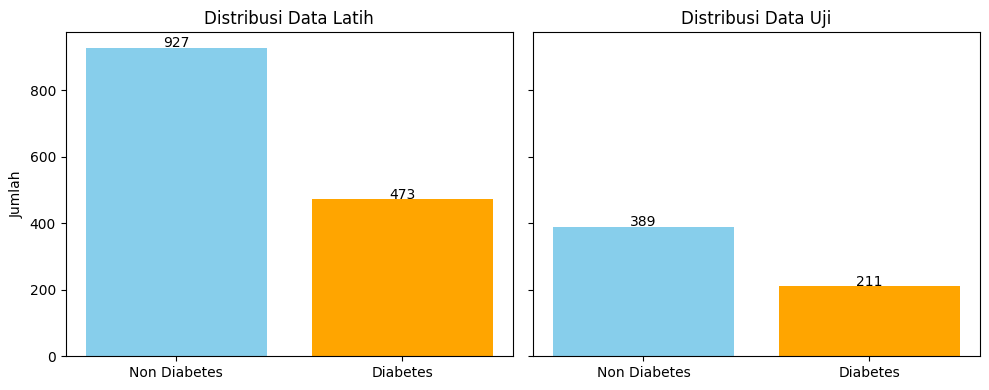

In [24]:
# distribusi kelas pada data latih dan data uji
train_y_counts = y_train.value_counts()
test_y_counts = y_test.value_counts()
test_counts  = y_test.value_counts().reindex([0, 1], fill_value=0)

labels = ["Non Diabetes", "Diabetes"]
x = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(x, train_y_counts.values, color=["skyblue", "orange"])
axes[0].set_title("Distribusi Data Latih")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Jumlah")

axes[1].bar(x, test_counts.values, color=["skyblue", "orange"])
axes[1].set_title("Distribusi Data Uji")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)

# angka di atas bar (opsional tapi masih sederhana)
for ax, counts in zip(axes, [train_y_counts, test_counts]):
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

### Balancing Data

In [25]:
# balancing dengan SMOTE
jumlah_per_kelas = y_train.value_counts()
jumlah_kelas_mayoritas = jumlah_per_kelas.max()
jumlah_kelas_minoritas = jumlah_per_kelas.min()
IR = jumlah_kelas_mayoritas / jumlah_kelas_minoritas
print(f"Imbalance Ratio: {IR}")

if IR > 1.5:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
else:
    print("Data sudah cukup seimbang")

Imbalance Ratio: 1.959830866807611


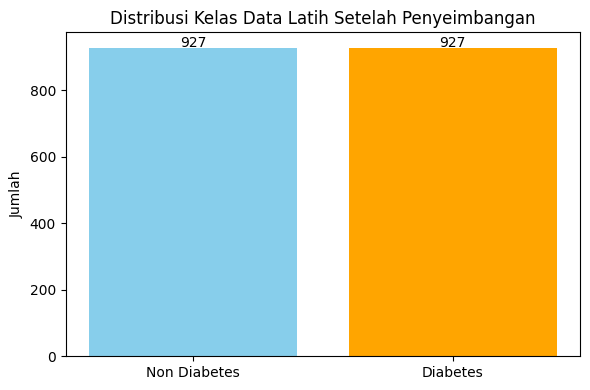

In [26]:
counts_smote =y_train_smote.value_counts()

plt.figure(figsize=(6, 4))
plt.bar([0, 1], counts_smote.values, color=["skyblue", "orange"])
plt.xticks([0, 1], ["Non Diabetes", "Diabetes"])
plt.ylabel("Jumlah")
plt.title("Distribusi Kelas Data Latih Setelah Penyeimbangan")

for i, v in enumerate(counts_smote.values):
    plt.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

## UJI COBA SKENARIO

In [27]:
# Cross-validation dengan KFold
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for split, (train_index, validasi_index) in enumerate(kfold.split(X_train_smote, y_train_smote), 1):
    print(f"split {split}:\n")
    print(f"Jumlah data train: {len(train_index)}")
    print(f"Jumlah data validation: {len(validasi_index)}\n")
    print(f"Train index: {', '.join(map(str, train_index))}")
    print(f"Validation index:  {', '.join(map(str, validasi_index))}\n")

split 1:

Jumlah data train: 1483
Jumlah data validation: 371

Train index: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 50, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 64, 66, 68, 72, 74, 75, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 112, 113, 114, 116, 117, 118, 119, 120, 121, 122, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 139, 140, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 164, 165, 166, 167, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 186, 187, 189, 190, 191, 193, 195, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 211, 213, 214, 215, 216, 217, 219, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 232, 234, 235, 236, 238, 241, 242, 243, 244, 245, 246, 248, 2

In [28]:
def plot_confusion_matrix(nama_skenario,y_asli, y_prediksi ):
    judul = nama_skenario
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_asli, y_prediksi)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non Diabetes", "Diabetes"],
                yticklabels=["Non Diabetes", "Diabetes"])
    ax.set_title(f"Confusion Matrix – {judul}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
    plt.tight_layout()
    plt.show()
    plt.close(fig)
def evaluasi_testing(nama_skenario, y_asli, y_prediksi):
    judul = f"{nama_skenario}"
    akurasi = accuracy_score(y_asli, y_prediksi)
    presisi = precision_score(y_asli, y_prediksi, zero_division=0)
    recall  = recall_score(y_asli, y_prediksi, zero_division=0)
    f1      = f1_score(y_asli, y_prediksi, zero_division=0)
    print(f"  Hasil Evaluasi Testing – {judul}")
    print(f"  Akurasi  : {akurasi:.4f}")
    print(f"  Presisi  : {presisi:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    return {
        "Model"   : judul,
        "Akurasi" : round(akurasi, 4),
        "Presisi" : round(presisi, 4),
        "Recall"  : round(recall,  4),
        "F1-Score": round(f1,      4),
    }

### Skenario 1 (KNN)

In [29]:
param_grid_knn = {
    "n_neighbors": [5, 7, 9, 11, 13, 15, 17, 19],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn.fit(X_train_smote, y_train_smote)
print(f"KNN Best Score: {grid_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_knn.best_params_}")
results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx = grid_knn.best_index_
best_idx = grid_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn.best_score_:.4f}")
knn_final = grid_knn.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Best Score: 0.9439
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Fold 1: 0.9461
Fold 2: 0.9380
Fold 3: 0.9299
Fold 4: 0.9434
Fold 5: 0.9622
Mean: 0.9439


In [30]:
print(f"Metrik Jarak: {knn_final.effective_metric_}")
print(f"Jumlah Sampel Latihan: {knn_final.n_samples_fit_}")

Metrik Jarak: manhattan
Jumlah Sampel Latihan: 1854


In [31]:
out_dir = Path("for_deployment")
joblib.dump(knn_final, out_dir / "knn_model.joblib")
knn_info = {
    "model": "KNN",
    "cv": {
        "n_folds": 5,
        "n_candidates": 48,
        "total_fits": 240,
    },
    "best_score": 0.9439,
    "best_params": {"metric": "manhattan", "n_neighbors": 5, "weights": "distance"},
    "fold_scores": [0.9461, 0.9380, 0.9299, 0.9434, 0.9622],
    "mean": 0.9439,
}
with open(out_dir / "knn_info.json", "w", encoding="utf-8") as f:
    json.dump(knn_info, f, indent=2, ensure_ascii=False)

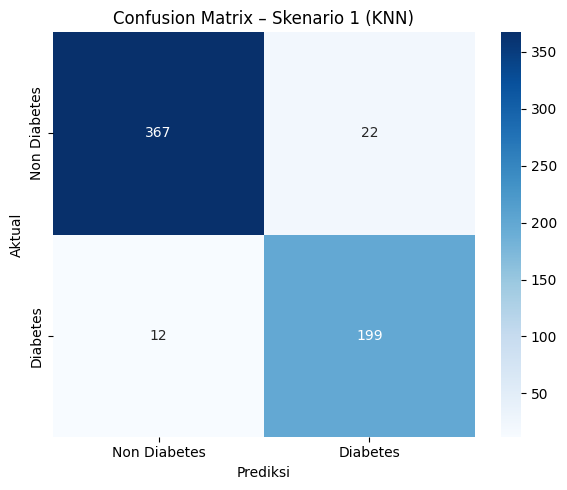

  Hasil Evaluasi Testing – Skenario 1 (KNN)
  Akurasi  : 0.9433
  Presisi  : 0.9005
  Recall   : 0.9431
  F1-Score : 0.9213


In [32]:
y_pred_knn_final = knn_final.predict(X_test)
plot_confusion_matrix("Skenario 1 (KNN)", y_test, y_pred_knn_final)
hasil_knn_final = evaluasi_testing("Skenario 1 (KNN)", y_test, y_pred_knn_final)

### Skenario 2 (LR)

In [33]:
# membuat model Logistic Regression dengan GridSearchCV
param_grid_lr = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l1", "l2"],
}
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_lr.fit(X_train_smote, y_train_smote)
print(f"LR Best Score: {grid_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_lr.best_params_}")
results_lr = pd.DataFrame(grid_lr.cv_results_)
best_idx = grid_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_lr.best_score_:.4f}")
lr_final = grid_lr.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score: 0.7481
LR Best Params: {'C': np.float64(0.012742749857031334), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7601
Fold 2: 0.7089
Fold 3: 0.7466
Fold 4: 0.7655
Fold 5: 0.7595
Mean: 0.7481


In [34]:
print(f"Koefisien (Bobot): \n{lr_final.coef_}")
print(f"Intercept (Bias): {lr_final.intercept_}")
print(f"Jumlah Iterasi: {lr_final.n_iter_}")

Koefisien (Bobot): 
[[ 0.27976254  0.64898804 -0.02699145  0.12672871  0.24276224  0.21146158
   0.08651063  0.3207088 ]]
Intercept (Bias): [-0.51686684]
Jumlah Iterasi: [4]


In [35]:
out_dir = Path("for_deployment")
joblib.dump(lr_final, out_dir / "lr_model.joblib")

# 2) simpan info hasilnya (boleh JSON)
lr_info = {
    "model": "LogisticRegression",
    "cv": {
        "n_folds": 5,
        "n_candidates": 80,
        "total_fits": 400,
    },
    "best_score": 0.7481,
    "best_params": {
        "C": 0.012742749857031334,   # pastikan float biasa (bukan np.float64) biar aman di JSON
        "penalty": "l2",
        "solver": "liblinear",
    },
    "fold_scores": [0.7601, 0.7089, 0.7466, 0.7655, 0.7595],
    "mean": 0.7481,

    # tambahan yang kamu minta
    "coef": [
        [ 0.27976254, 1.40163103, -0.0347297, 0.25106864, 0.27961099, 0.55780767, 0.22048715, 0.48571201]
    ],
    "intercept": [-1.17551152],
    "n_iter": [3],
}

with open(out_dir / "lr_info.json", "w", encoding="utf-8") as f:
    json.dump(lr_info, f, indent=2, ensure_ascii=False)

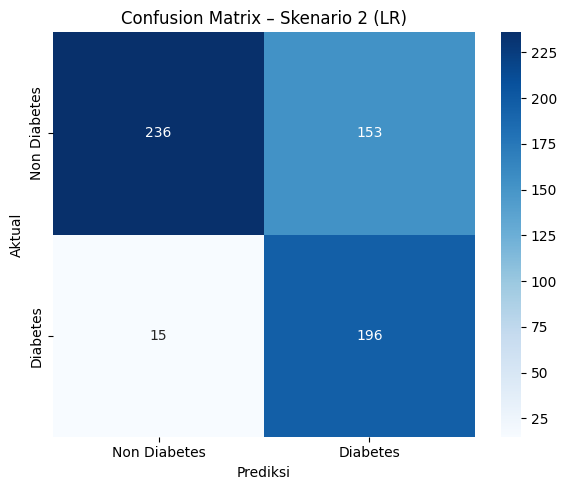

  Hasil Evaluasi Testing – Skenario 2 (LR)
  Akurasi  : 0.7200
  Presisi  : 0.5616
  Recall   : 0.9289
  F1-Score : 0.7000


In [36]:
y_pred_lr_final = lr_final.predict(X_test)
plot_confusion_matrix("Skenario 2 (LR)", y_test, y_pred_lr_final)
hasil_lr_final = evaluasi_testing("Skenario 2 (LR)", y_test, y_pred_lr_final)

### Skenario 3 (SVM)

In [37]:
# membuat model SVM dengan GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"],
}
grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm.fit(X_train_smote, y_train_smote)
print(f"SVM Best Score: {grid_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_svm.best_params_}")
results_svm = pd.DataFrame(grid_svm.cv_results_)
best_idx = grid_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm.best_score_:.4f}")
svm_final = grid_svm.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score: 0.9186
SVM Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.9326
Fold 2: 0.9245
Fold 3: 0.9057
Fold 4: 0.9030
Fold 5: 0.9270
Mean: 0.9186


In [38]:
print(f"Indeks Support Vectors: {svm_final.support_}")
print(f"Jumlah Support Vectors per kelas: {svm_final.n_support_[0]} (kelas 0), {svm_final.n_support_[1]} (kelas 1)")
# print(f"Bobot Fitur (coef_): \n{svm_final.coef_}")
print(f"Konstanta Bias (intercept_): {svm_final.intercept_}")
print(f"Total Support Vectors: {sum(svm_final.n_support_)}")

Indeks Support Vectors: [  16   18   25   36   68   78   87   88  114  125  131  135  150  151
  161  176  188  195  197  203  209  212  217  224  225  237  252  253
  276  296  304  309  313  315  333  337  344  350  353  359  367  369
  372  375  377  383  388  406  412  413  419  425  428  430  443  448
  449  452  461  469  477  478  480  482  487  493  507  516  520  548
  550  557  561  565  567  575  578  579  580  594  596  605  606  607
  608  612  618  634  646  647  653  654  655  662  672  676  679  681
  682  684  692  695  706  708  722  723  727  730  733  736  737  752
  757  760  765  769  773  774  780  782  799  804  808  816  827  828
  829  836  837  840  845  858  861  871  877  878  890  892  898  901
  906  912  915  916  919  924  929  931  936  940  942  945  946  953
  955  956  959  960  962  975  977 1001 1002 1003 1007 1009 1014 1020
 1027 1028 1031 1033 1038 1046 1057 1060 1065 1066 1068 1069 1071 1073
 1082 1087 1090 1097 1101 1104 1107 1111 1113 1118 11

In [39]:
out_dir = Path("for_deployment")

# simpan model
joblib.dump(svm_final, out_dir / "svm_model.joblib")

# simpan info (hardcode)
svm_info = {
    "model": "SVM",
    "cv": {
        "n_folds": 5,
        "n_candidates": 20,
        "total_fits": 100,
    },
    "best_score": 0.9186,
    "best_params": {
        "C": 1000,
        "gamma": "scale",
        "kernel": "rbf",
    },
    "fold_scores": [0.9326, 0.9245, 0.9057, 0.9030, 0.9270],
    "mean": 0.9186,
}

with open(out_dir / "svm_info.json", "w", encoding="utf-8") as f:
    json.dump(svm_info, f, indent=2, ensure_ascii=False)


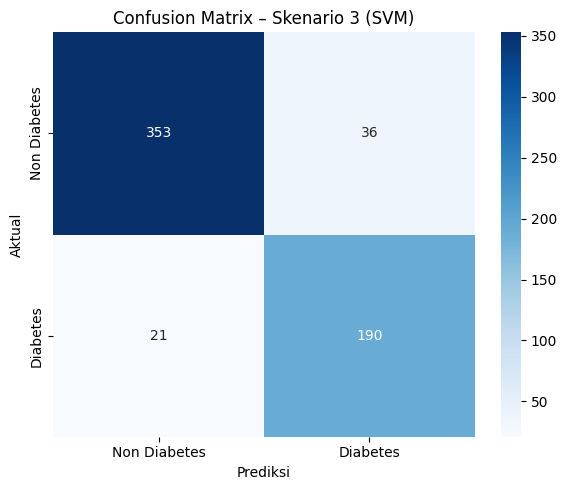

  Hasil Evaluasi Testing – Skenario 3 (SVM)
  Akurasi  : 0.9050
  Presisi  : 0.8407
  Recall   : 0.9005
  F1-Score : 0.8696


In [40]:
y_pred_svm_final = svm_final.predict(X_test)
plot_confusion_matrix("Skenario 3 (SVM)", y_test, y_pred_svm_final)
hasil_svm_final = evaluasi_testing("Skenario 3 (SVM)", y_test, y_pred_svm_final)

### Skenario 4 (ANN)

In [41]:
# membuat model ann dengan GridSearchCV
param_grid_ann = {
    "max_iter": [100, 500, 1000],
    "hidden_layer_sizes": [(100,), (50, 50), (30, 20), (20, 10)],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
}
grid_ann = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann.fit(X_train_smote, y_train_smote)
print(f"ANN Best Score: {grid_ann.best_score_:.4f}")
print(f"ANN Best Params: {grid_ann.best_params_}")
results_ann = pd.DataFrame(grid_ann.cv_results_)
best_idx = grid_ann.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann.best_score_:.4f}")
ann_final = grid_ann.best_estimator_

Fitting 5 folds for each of 144 candidates, totalling 720 fits
ANN Best Score: 0.8279
ANN Best Params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'max_iter': 1000}
Fold 1: 0.8140
Fold 2: 0.8140
Fold 3: 0.8544
Fold 4: 0.8248
Fold 5: 0.8324
Mean: 0.8279


In [42]:
# Hasil pelatihan ANN
print(ann_final.loss_)
print(ann_final.n_iter_)
print(ann_final.t_)
print(ann_final.n_layers_)
print(ann_final.n_outputs_)
print(ann_final.out_activation_)
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_final.intercepts_]}")

0.343953785934186
441
817614
4
1
logistic

Shape Matriks Bobot (coefs_): [(8, 50), (50, 50), (50, 1)]
Shape Vektor Bias (intercepts_): [(50,), (50,), (1,)]


In [43]:
out_dir = Path("for_deployment")

# simpan model
joblib.dump(ann_final, out_dir / "ann_model.joblib")

# simpan info (hardcode)
ann_info = {
    "model": "ANN",
    "cv": {
        "n_folds": 5,
        "n_candidates": 144,
        "total_fits": 720,
    },
    "best_score": 0.8279,
    "best_params": {
        "activation": "relu",
        "alpha": 0.001,
        "hidden_layer_sizes": [50, 50],  # JSON tidak punya tuple, jadi pakai list
        "max_iter": 1000,
    },
    "fold_scores": [0.8140, 0.8140, 0.8544, 0.8248, 0.8324],
    "mean": 0.8279,
}

with open(out_dir / "ann_info.json", "w", encoding="utf-8") as f:
    json.dump(ann_info, f, indent=2, ensure_ascii=False)

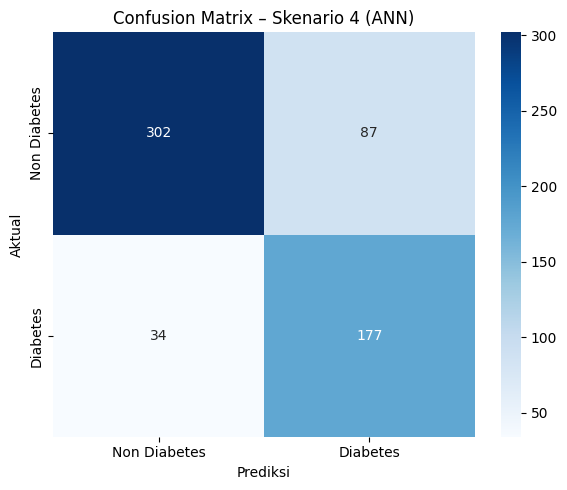

  Hasil Evaluasi Testing – Skenario 4 (ANN)
  Akurasi  : 0.7983
  Presisi  : 0.6705
  Recall   : 0.8389
  F1-Score : 0.7453


In [44]:
y_pred_ann_final = ann_final.predict(X_test)
plot_confusion_matrix("Skenario 4 (ANN)", y_test, y_pred_ann_final)
hasil_ann_final = evaluasi_testing("Skenario 4 (ANN)", y_test, y_pred_ann_final)

### MEMBUAT DATA TRAINING DAN TESTING UNTUK META LEARNER

In [45]:
prediksi_lr = cross_val_predict(lr_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_knn = cross_val_predict(knn_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_svm = cross_val_predict(svm_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
prediksi_ann = cross_val_predict(ann_final, X_train_smote, y_train_smote, cv=kfold, method="predict_proba")
fitur_meta = np.column_stack([
    prediksi_lr,
    prediksi_knn,
    prediksi_svm,
    prediksi_ann,
    # y_train_smote
])
df_fitur_meta = pd.DataFrame(
    fitur_meta,
    columns=[
        "lr_prob_0", "lr_prob_1",
        "knn_prob_0", "knn_prob_1",
        "svm_prob_0", "svm_prob_1",
        "ann_prob_0", "ann_prob_1",
        # "Outcome"
    ],
)
# df_fitur_meta["Outcome"] = df_fitur_meta["Outcome"].astype(int)

In [46]:
df_fitur_meta.to_excel("fitur_meta_training.xlsx", index=False)
df_fitur_meta

,lr_prob_0,lr_prob_1,knn_prob_0,knn_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.485175,0.514825,0.000000,1.000000,0.260130,0.739870,0.270256,0.729744
1,0.504863,0.495137,1.000000,0.000000,0.680113,0.319887,0.888421,0.111579
2,0.447943,0.552057,1.000000,0.000000,0.992605,0.007395,0.962136,0.037864
3,0.498009,0.501991,0.000000,1.000000,0.260242,0.739758,0.862058,0.137942
4,0.520744,0.479256,0.603858,0.396142,0.569228,0.430772,0.644966,0.355034
...,...,...,...,...,...,...,...,...
1849,0.424088,0.575912,0.000000,1.000000,0.251996,0.748004,0.059807,0.940193
1850,0.478812,0.521188,0.000000,1.000000,0.267627,0.732373,0.179098,0.820902
1851,0.488084,0.511916,0.176928,0.823072,0.333799,0.666201,0.276764,0.723236
1852,0.435854,0.564146,0.000000,1.000000,0.225706,0.774294,0.362246,0.637754


In [47]:
# membuat fitur testing meta learner dengan prediksi probabilitas
prediksi_uji_lr = lr_final.predict_proba(X_test)
prediksi_uji_knn = knn_final.predict_proba(X_test)
prediksi_uji_svm = svm_final.predict_proba(X_test)
prediksi_uji_ann = ann_final.predict_proba(X_test)
fitur_meta_uji = np.column_stack([prediksi_uji_lr, prediksi_uji_knn, prediksi_uji_svm, prediksi_uji_ann])
df_fitur_meta_uji = pd.DataFrame(
    fitur_meta_uji,
    columns=df_fitur_meta.columns,
)

In [48]:
df_fitur_meta_uji
df_fitur_meta_uji.to_excel("fitur_meta_testing.xlsx", index=False)

In [49]:
X_meta_latih = df_fitur_meta
y_meta_latih = y_train_smote
X_meta_uji = df_fitur_meta_uji
y_meta_uji = y_test

### Skenario 5 Stacking (Meta-KNN)

In [50]:
# membuat model KNN Meta dengan GridSearchCV
grid_knn_meta = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn_meta.fit(X_meta_latih, y_meta_latih)
print(f"KNN Meta Best Score: {grid_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_knn_meta.best_params_}")
results_knn_meta = pd.DataFrame(grid_knn_meta.cv_results_)
best_idx = grid_knn_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn_meta.best_score_:.4f}")
knn_meta_final = grid_knn_meta.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Meta Best Score: 0.9455
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'}
Fold 1: 0.9488
Fold 2: 0.9380
Fold 3: 0.9353
Fold 4: 0.9488
Fold 5: 0.9568
Mean: 0.9455


In [51]:
print(f"Metrik Jarak: {knn_meta_final.effective_metric_}")
print(f"Jumlah Sampel Latihan: {knn_meta_final.n_samples_fit_}")

Metrik Jarak: manhattan
Jumlah Sampel Latihan: 1854


In [52]:
joblib.dump(knn_meta_final,    out_dir / "knn_meta_model.joblib")
knn_meta_info = {
    "model": "KNN_META",
    "cv": {"n_folds": 5, "n_candidates": 48, "total_fits": 240},
    "best_score": 0.9455,
    "best_params": {"metric": "manhattan", "n_neighbors": 13, "weights": "uniform"},
    "fold_scores": [0.9488, 0.9380, 0.9353, 0.9488, 0.9568],
    "mean": 0.9455,
}
with open(out_dir / "knn_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(knn_meta_info, f, indent=2, ensure_ascii=False)


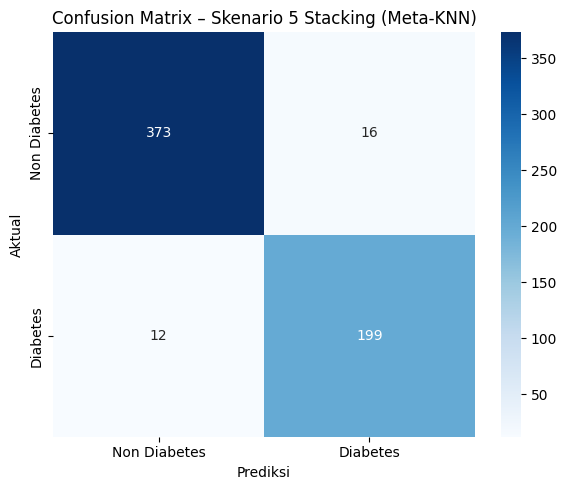

  Hasil Evaluasi Testing – Skenario 5 Stacking (Meta-KNN)
  Akurasi  : 0.9533
  Presisi  : 0.9256
  Recall   : 0.9431
  F1-Score : 0.9343


In [53]:
y_pred_knn_meta_final = knn_meta_final.predict(X_meta_uji)
plot_confusion_matrix("Skenario 5 Stacking (Meta-KNN)", y_test, y_pred_knn_meta_final)
hasil_knn_meta_final = evaluasi_testing("Skenario 5 Stacking (Meta-KNN)", y_test, y_pred_knn_meta_final)

### Skenario 6 Stacking (Meta-LR)

In [54]:
# membuat model Logistic Regression Meta dengan GridSearchCV
grid_logreg_meta = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_logreg_meta.fit(X_meta_latih, y_meta_latih)
print(f"LogReg Meta Best Score: {grid_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_logreg_meta.best_params_}")
results_logreg_meta = pd.DataFrame(grid_logreg_meta.cv_results_)
best_idx = grid_logreg_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_logreg_meta.best_score_:.4f}")
logreg_meta_final = grid_logreg_meta.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LogReg Meta Best Score: 0.9439
LogReg Meta Best Params: {'C': np.float64(0.03359818286283781), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.9488
Fold 2: 0.9434
Fold 3: 0.9380
Fold 4: 0.9353
Fold 5: 0.9541
Mean: 0.9439


In [55]:
print(f"Koefisien (Bobot): \n{logreg_meta_final.coef_}")
print(f"Intercept (Bias): {logreg_meta_final.intercept_}")
print(f"Jumlah Iterasi: {logreg_meta_final.n_iter_}")

Koefisien (Bobot): 
[[-0.08409777  0.00474019 -1.66671327  1.58735569 -0.85638585  0.77702826
  -0.6105554   0.53119782]]
Intercept (Bias): [-0.07935758]
Jumlah Iterasi: [5]


In [56]:
joblib.dump(logreg_meta_final, out_dir / "logreg_meta_model.joblib")
logreg_meta_info = {
    "model": "LogReg_META",
    "cv": {"n_folds": 5, "n_candidates": 80, "total_fits": 400},
    "best_score": 0.9439,
    "best_params": {
        "C": 0.03359818286283781,  # float biasa biar aman di JSON
        "penalty": "l2",
        "solver": "liblinear",
    },
    "fold_scores": [0.9488, 0.9434, 0.9380, 0.9353, 0.9541],
    "mean": 0.9439,
}
with open(out_dir / "logreg_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(logreg_meta_info, f, indent=2, ensure_ascii=False)

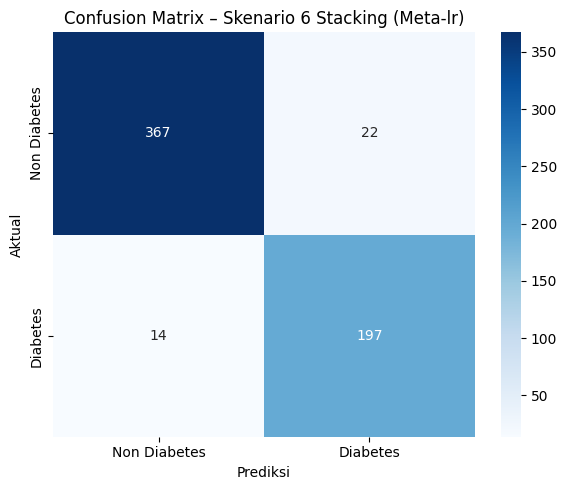

  Hasil Evaluasi Testing – Skenario 6 Stacking (Meta-lr)
  Akurasi  : 0.9400
  Presisi  : 0.8995
  Recall   : 0.9336
  F1-Score : 0.9163


In [57]:
y_pred_lr_meta_final = logreg_meta_final.predict(X_meta_uji)
plot_confusion_matrix("Skenario 6 Stacking (Meta-lr)", y_test, y_pred_lr_meta_final)
hasil_lr_meta_final = evaluasi_testing("Skenario 6 Stacking (Meta-lr)", y_test, y_pred_lr_meta_final)

### Skenario 7 Stacking (Meta-SVM)

In [58]:
# membuat model Support Vector Machine Meta dengan GridSearchCV
grid_svm_meta = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm_meta.fit(X_meta_latih, y_meta_latih)
print(f"SVM Meta Best Score: {grid_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_svm_meta.best_params_}")
results_svm_meta = pd.DataFrame(grid_svm_meta.cv_results_)
best_idx = grid_svm_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm_meta.best_score_:.4f}")
svm_meta_final = grid_svm_meta.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


SVM Meta Best Score: 0.9434
SVM Meta Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Fold 1: 0.9461
Fold 2: 0.9407
Fold 3: 0.9326
Fold 4: 0.9407
Fold 5: 0.9568
Mean: 0.9434


In [59]:
print(f"Indeks Support Vectors: {svm_meta_final.support_}")
print(f"Jumlah Support Vectors per kelas: {svm_meta_final.n_support_}")
print(f"Bobot Fitur (coef_): \n{svm_meta_final.coef_}")
print(f"Konstanta Bias (intercept_): {svm_meta_final.intercept_}")

Indeks Support Vectors: [   4    8   16   18   36   39   41   58   78   87   88  120  125  127
  140  150  161  163  212  221  223  228  251  252  270  273  294  300
  304  313  316  318  331  333  343  344  350  353  363  371  372  375
  380  383  406  418  419  425  428  437  449  459  461  468  477  493
  557  561  575  578  598  603  608  626  634  664  672  676  679  681
  682  692  695  719  733  760  765  769  773  782  816  820  828  829
  890  915  924  948  955  963 1009 1038 1046 1055 1057 1069 1078 1090
 1097 1115 1119 1132 1158 1172 1178 1187 1189 1203 1205 1206 1211 1216
 1217 1220 1231 1234 1248 1249 1263 1268 1274 1286 1297 1298 1311 1324
 1328 1331 1344 1346 1353 1393 1399   11   13   26   34   51   66   85
   96  128  144  145  149  155  177  194  231  280  303  336  394  407
  417  420  442  465  501  514  562  577  616  624  629  637  687  748
  758  761  786  850  857  875  961  966  969  979 1008 1012 1022 1024
 1025 1041 1102 1106 1130 1162 1166 1191 1229 1251 12

In [60]:
joblib.dump(svm_meta_final,out_dir / "svm_meta_model.joblib")
svm_meta_info = {
    "model": "SVM_META",
    "cv": {"n_folds": 5, "n_candidates": 20, "total_fits": 100},
    "best_score": 0.9434,
    "best_params": {"C": 0.1, "gamma": "scale", "kernel": "linear"},
    "fold_scores": [0.9461, 0.9407, 0.9326, 0.9407, 0.9568],
    "mean": 0.9434,
}
with open(out_dir / "svm_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(svm_meta_info, f, indent=2, ensure_ascii=False)


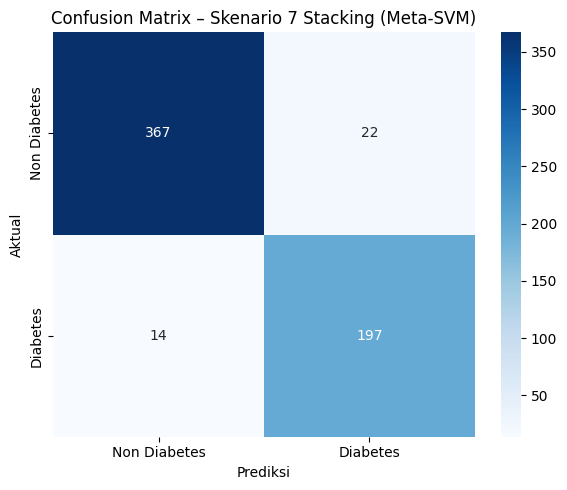

  Hasil Evaluasi Testing – Skenario 7 Stacking (Meta-SVM)
  Akurasi  : 0.9400
  Presisi  : 0.8995
  Recall   : 0.9336
  F1-Score : 0.9163


In [61]:
y_pred_svm_meta_final = svm_meta_final.predict(X_meta_uji)
plot_confusion_matrix("Skenario 7 Stacking (Meta-SVM)", y_test, y_pred_svm_meta_final)
hasil_svm_meta_final = evaluasi_testing("Skenario 7 Stacking (Meta-SVM)", y_test, y_pred_svm_meta_final)

### Skenario 8 Stacking (Meta-ANN)

In [62]:
# membuat model ANN Meta dengan GridSearchCV
grid_ann_meta = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann_meta.fit(X_meta_latih, y_meta_latih)
print(f"ANN Meta Best Score: {grid_ann_meta.best_score_:.4f}")
print(f"ANN Meta Best Params: {grid_ann_meta.best_params_}")
results_ann_meta = pd.DataFrame(grid_ann_meta.cv_results_)
best_idx = grid_ann_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann_meta.best_score_:.4f}")
ann_meta_final = grid_ann_meta.best_estimator_

Fitting 5 folds for each of 144 candidates, totalling 720 fits
ANN Meta Best Score: 0.9455
ANN Meta Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (20, 10), 'max_iter': 100}
Fold 1: 0.9542
Fold 2: 0.9380
Fold 3: 0.9380
Fold 4: 0.9299
Fold 5: 0.9676
Mean: 0.9455


In [63]:
# Hasil pelatihan ANN
print(ann_meta_final.loss_)
print(ann_meta_final.n_iter_)
print(ann_meta_final.t_)
print(ann_meta_final.n_layers_)
print(ann_meta_final.n_outputs_)
print(ann_meta_final.out_activation_)
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_meta_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_meta_final.intercepts_]}")

0.16239437506918214
68
126072
4
1
logistic

Shape Matriks Bobot (coefs_): [(8, 20), (20, 10), (10, 1)]
Shape Vektor Bias (intercepts_): [(20,), (10,), (1,)]


In [64]:
joblib.dump(ann_meta_final,    out_dir / "ann_meta_model.joblib")
ann_meta_info = {
    "model": "ANN_META",
    "cv": {"n_folds": 5, "n_candidates": 144, "total_fits": 720},
    "best_score": 0.9455,
    "best_params": {
        "activation": "relu",
        "alpha": 0.0001,
        "hidden_layer_sizes": [20, 10],  # JSON tidak punya tuple → pakai list
        "max_iter": 100,
    },
    "fold_scores": [0.9542, 0.9380, 0.9380, 0.9299, 0.9676],
    "mean": 0.9455,
}
with open(out_dir / "ann_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(ann_meta_info, f, indent=2, ensure_ascii=False)

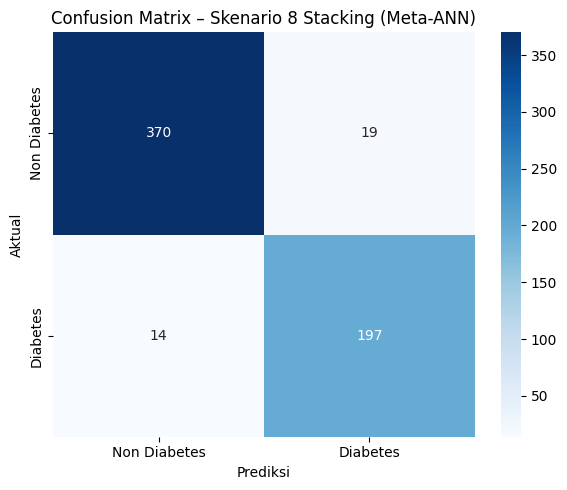

  Hasil Evaluasi Testing – Skenario 8 Stacking (Meta-ANN)
  Akurasi  : 0.9450
  Presisi  : 0.9120
  Recall   : 0.9336
  F1-Score : 0.9227


In [65]:
y_pred_ann_meta_final = ann_meta_final.predict(X_meta_uji)
plot_confusion_matrix("Skenario 8 Stacking (Meta-ANN)", y_test, y_pred_ann_meta_final)
hasil_ann_meta_final = evaluasi_testing("Skenario 8 Stacking (Meta-ANN)", y_test, y_pred_ann_meta_final)

In [66]:
hasil_semua = [
    hasil_knn_final,
    hasil_lr_final,
    hasil_svm_final,
    hasil_ann_final,
    hasil_knn_meta_final,
    hasil_lr_meta_final,
    hasil_svm_meta_final,
    hasil_ann_meta_final,
]

df_perbandingan = pd.DataFrame(hasil_semua)
df_perbandingan.index = range(1, len(df_perbandingan) + 1)
df_perbandingan.index.name = "No"
display(df_perbandingan)
print("\nModel Terbaik per Metrik:")
for metrik in ["Akurasi", "Presisi", "Recall", "F1-Score"]:
    best_idx = df_perbandingan[metrik].idxmax()
    best_model = df_perbandingan.loc[best_idx, "Model"]
    best_val   = df_perbandingan.loc[best_idx, metrik]
    print(f"  {metrik:10s}: {best_model} ({best_val:.4f})")

,Model,Akurasi,Presisi,Recall,F1-Score
No,,,,,
1,Skenario 1 (KNN),0.9433,0.9005,0.9431,0.9213
2,Skenario 2 (LR),0.7200,0.5616,0.9289,0.7000
3,Skenario 3 (SVM),0.9050,0.8407,0.9005,0.8696
4,Skenario 4 (ANN),0.7983,0.6705,0.8389,0.7453
5,Skenario 5 Stacking (Meta-KNN),0.9533,0.9256,0.9431,0.9343
6,Skenario 6 Stacking (Meta-lr),0.9400,0.8995,0.9336,0.9163
7,Skenario 7 Stacking (Meta-SVM),0.9400,0.8995,0.9336,0.9163
8,Skenario 8 Stacking (Meta-ANN),0.9450,0.9120,0.9336,0.9227



Model Terbaik per Metrik:
  Akurasi   : Skenario 5 Stacking (Meta-KNN) (0.9533)
  Presisi   : Skenario 5 Stacking (Meta-KNN) (0.9256)
  Recall    : Skenario 1 (KNN) (0.9431)
  F1-Score  : Skenario 5 Stacking (Meta-KNN) (0.9343)


In [67]:
import pandas as pd

def cv_results_to_export(nama_model, results_df):
    df = results_df[["params", "mean_test_score", "rank_test_score"]].copy()
    df = df.dropna(subset=["mean_test_score"])

    df.rename(columns={
        "params": "Kombinasi Parameter",
        "mean_test_score": "Rata Rata",
        "rank_test_score": "Peringkat",
    }, inplace=True)

    df.insert(0, "Nama Model", nama_model)
    df["Kombinasi Parameter"] = df["Kombinasi Parameter"].astype(str)
    return df

# =========================
# BASE (sheet 1)
# =========================
df_base = pd.concat([
    cv_results_to_export("KNN", results_knn),
    cv_results_to_export("LogReg", results_lr),
    cv_results_to_export("SVM", results_svm),
    cv_results_to_export("ANN", results_ann),
], ignore_index=True)

df_base = df_base.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
df_base.insert(0, "No", range(1, len(df_base) + 1))

# =========================
# META (sheet 2)
# =========================
df_meta = pd.concat([
    cv_results_to_export("KNN", results_knn_meta),
    cv_results_to_export("LogReg", results_logreg_meta),
    cv_results_to_export("SVM", results_svm_meta),
    cv_results_to_export("ANN", results_ann_meta),
], ignore_index=True)

df_meta = df_meta.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
df_meta.insert(0, "No", range(1, len(df_meta) + 1))

# =========================
# EXPORT (2 sheet)
# =========================
output_excel = "rekap_kombinasi_parameter_base_dan_meta.xlsx"
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df_base.to_excel(writer, index=False, sheet_name="Base")
    df_meta.to_excel(writer, index=False, sheet_name="Meta")

print("Berhasil membuat:", output_excel)
print("Total baris Base:", len(df_base))
print("Total baris Meta:", len(df_meta))

Berhasil membuat: rekap_kombinasi_parameter_base_dan_meta.xlsx
Total baris Base: 272
Total baris Meta: 272
